In [1]:
import pdal
import geopandas as gpd
import json
import os
from shapely.geometry import mapping, MultiPoint, Point
import alphashape

In [2]:
# Carregar feições
gdf = gpd.read_file('data/SIRGAS_GPKG_favela.gpkg')
gdf.geometry = gdf.buffer(0)

favelas_test = [
    "Heliópolis",
    "Cocaia I",
    "Paraisópolis",
    "Futuro Melhor",
    "São Remo"
]

gdf_favelas = gdf[gdf['fv_nome'].isin(favelas_test)]

# gdf_favelas tem múltiplas feições para algumas favalas como Heliópolis
# Vamos soldar as feições por nome
gdf_favelas = gdf_favelas.dissolve(by='fv_nome', as_index=False)

/Users/fernandogomes/miniconda3/envs/pdal/lib/python3.12/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Polygon' is converted to 'Polygon Z'
  return ogr_read(


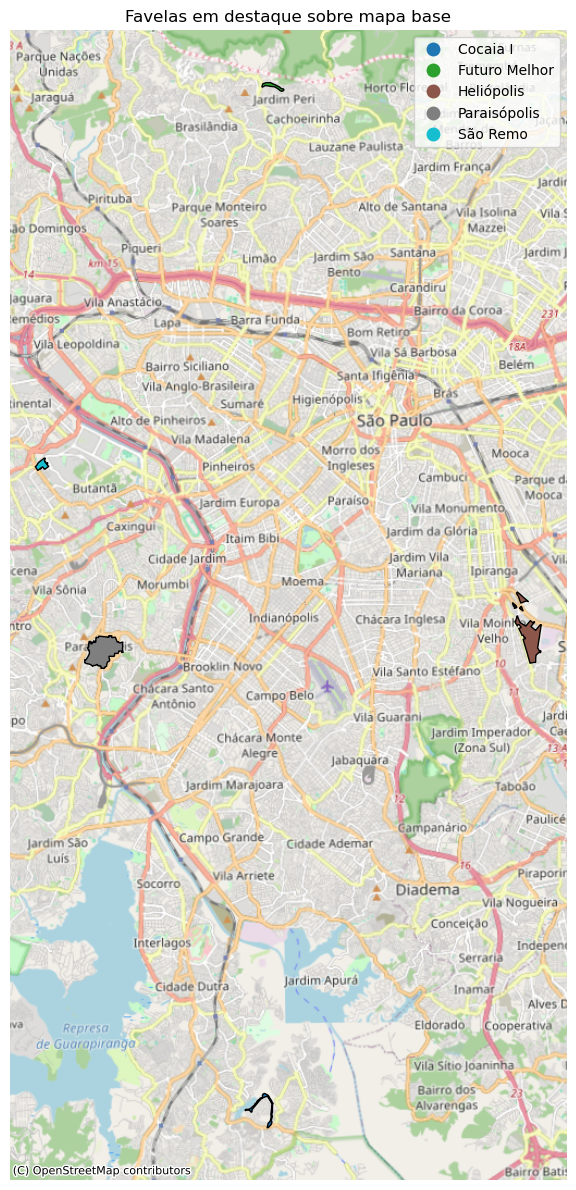

In [3]:
import contextily as ctx
import matplotlib.pyplot as plt

# Plotando as favelas filtradas com mapa base
fig, ax = plt.subplots(figsize=(20, 12))
# Filtrar as favelas de interesse
favelas_filtradas = gdf[gdf['fv_nome'].isin(favelas_test)]

# Plotando as favelas filtradas
favelas_filtradas.plot(ax=ax, alpha=1, edgecolor='black', column='fv_nome', legend=True)

# Adicionando mapa base em tons de cinza (menos saturação)
ctx.add_basemap(
    ax,
    crs=favelas_filtradas.crs,
    source=ctx.providers.OpenStreetMap.Mapnik,
    alpha=1.0
)

# Removendo eixos para dar mais destaque
ax.set_axis_off()
plt.title("Favelas em destaque sobre mapa base")
plt.tight_layout()
plt.show()

In [4]:
# Dicionário com anos, pastas e articulações
als = {
    2017: {
        "arquivos_laz": "../LiDAR-Sampa-2017",
        "articulacao": "data/quadricula_folha_mdt.zip",
        "atributo_quadricula": "cd_quadric",
        "nome_fn": lambda row, dados: f"MDS_color_{row[dados['atributo_quadricula']]}.laz"
    },
    2020: {
        "arquivos_laz": "../LiDAR-Sampa-2020",
        "articulacao": "data/quadricula_folha_mdt_mds_2020.zip",
        "atributo_quadricula": "cd_quadric",
        "nome_fn": lambda row, dados: f"MDS_{row[dados['atributo_quadricula']]}_1000.laz"
    },
    2024: {
        "arquivos_laz": "../LiDAR-Sampa-2024",
        "articulacao": "../LiDAR-Sampa-2024/poligonos_consolidados.gpkg",
        "atributo_quadricula": "nome_arquivo",
        "nome_fn": lambda row, dados: f'{row[dados["atributo_quadricula"]]}.laz' 
    }
}

In [5]:
def safe_alphashape(points, alpha=1.0):
    coords = list({(p.x, p.y) for p in points})  # remove duplicados
    if len(coords) < 3:
        return MultiPoint(coords).convex_hull  # devolve ponto ou linha ou polígono degenerado
    try:
        return alphashape.alphashape(coords, alpha)
    except Exception as e:
        print(f"⚠️ Erro no cluster: {e}")
        return MultiPoint(coords).convex_hull


In [ ]:
# Pasta de saída geral
os.makedirs("saidas", exist_ok=True)

# loop principal - recorte e gravação
for idx, favela in gdf_favelas.iterrows():
    nome = favela["fv_nome"]
    geom = favela.geometry
    
    print(f"Processando {nome}...")

    # cria pasta de saída se não existir
    pasta_saida = os.path.join("saidas", nome.replace(" ", "_"))
    os.makedirs(pasta_saida, exist_ok=True)
 
    gdf_single = gpd.GeoDataFrame(
        {"fv_nome": [nome], "geometry": [favela.geometry]},
        crs=gdf_favelas.crs
    )

    for ano, dados in als.items():
        print(f"\n=== Processando {ano} ===")
        gdf_art = gpd.read_file(dados['articulacao'])
        gdf_art = gdf_art.to_crs(gdf_favelas.crs)

        # Recorte das feições que caem na São Remo
        recorte = gpd.overlay(gdf_art, gdf_single, how="intersection")
        als[ano]["gdf"] = recorte

        print(f"{ano}: {len(recorte)} feições sobrepostas")

        # Pasta de saída por ano
        outdir = os.path.join(pasta_saida, str(ano))
        os.makedirs(outdir, exist_ok=True)

        arquivos_saida = []

        for idx, row in recorte.iterrows():
            # Ajuste: troque 'NOME' pelo campo que identifica a folha
            nome_folha = dados["nome_fn"](row, dados)   # aqui aplica a função definida no dicionário
            arquivo_laz = os.path.join(dados["arquivos_laz"], nome_folha)

            if not os.path.exists(arquivo_laz):
                print(f"⚠️ Arquivo não encontrado: {arquivo_laz}")
                continue

            # Converter geometria em GeoJSON para o filtro do PDAL
            geom = row.geometry

            if geom.geom_type == "MultiPolygon":
                # Constrói diretamente como MultiPolygon
                polygon = json.dumps(mapping(geom))
            elif geom.geom_type == "Polygon":
                polygon = json.dumps(mapping(geom))
            else:
                print(f"⚠️ Geometria ignorada (tipo: {geom.geom_type}): {nome_folha}")
                continue  # pula para a próxima feição

            out_laz = os.path.join(outdir, f"{nome_folha}_recorte.laz")
            arquivos_saida.append(out_laz)

            pipeline_json = {
                "pipeline": [
                    arquivo_laz,
                    {
                        "type": "filters.crop",
                        "polygon": polygon  # já está em formato GeoJSON
                    },
                    {
                        "type": "filters.hag_nn"
                    },
                    {
                        "type": "filters.ferry",
                        "dimensions": "Z => Z_orig"
                    },
                    {
                        "type": "writers.las",
                        "filename": out_laz,
                        "extra_dims": "HeightAboveGround=float32,Z_orig=float32"
                    }
                ]
            }
       
            pipeline = pdal.Pipeline(json.dumps(pipeline_json))
            pipeline.execute()
            print(f"✅ Recorte salvo: {out_laz}")

        # Juntar os recortes em um único arquivo do ano
        if arquivos_saida:
            merged_out = os.path.join(outdir, f"{nome}_{ano}.laz")

            readers = [{"type": "readers.las", "filename": f} for f in arquivos_saida]

            pipeline_merge = {
                "pipeline": readers + [
                    # 1) junta todos os readers em um só fluxo
                    {"type": "filters.merge", "tag": "merged"},

                    # 2) calcula as normais de cada ponto considerando apenas o eixo Z
                    {
                        "type": "filters.normal",
                        "knn": 8,
                        "tag": "with_normals",
                        "inputs": ["merged"]
                    },

                    # 3) branch A: NÃO vegetação -> Cluster
                    {
                        "type": "filters.cluster", 
                        "min_points": 9, 
                        "tolerance": 0.6, 
                        "inputs": ["with_normals"],
                        "is3d": "true",
                        "where": "(NormalZ >= 0.6 || NormalZ <= -0.6) && (Classification != 3 || Classification != 5)"
                    },

                    # 5) grava tudo, mantendo extras (ClusterID, HAG, etc.)
                    {"type": "writers.las", "filename": merged_out, "extra_dims": "all"}
                ]
            }

            pipeline = pdal.Pipeline(json.dumps(pipeline_merge))
            count = pipeline.execute()
            arr = pipeline.arrays[0]   # numpy structured array com os pontos
            # pdal.Pipeline(json.dumps(pipeline_merge)).execute()
            print(f"🎯 Nuvem final salva: {merged_out}")
        else:
            print(f"⚠️ Nenhuma nuvem processada para {ano}")

        # remove os arquivos individuais gerados pelo recorte
        for arquivo in arquivos_saida:
            os.remove(arquivo)
            print(f"🗑️ Arquivo temporário removido: {arquivo}")
        
        break

Processando Cocaia I...

=== Processando 2017 ===
2017: 6 feições sobrepostas
✅ Recorte salvo: saidas/Cocaia_I/2017/MDS_color_3336-353.laz_recorte.laz
✅ Recorte salvo: saidas/Cocaia_I/2017/MDS_color_3336-344.laz_recorte.laz
✅ Recorte salvo: saidas/Cocaia_I/2017/MDS_color_3336-343.laz_recorte.laz
✅ Recorte salvo: saidas/Cocaia_I/2017/MDS_color_3212-121.laz_recorte.laz
✅ Recorte salvo: saidas/Cocaia_I/2017/MDS_color_3212-112.laz_recorte.laz
✅ Recorte salvo: saidas/Cocaia_I/2017/MDS_color_3212-111.laz_recorte.laz
🎯 Nuvem final salva: saidas/Cocaia_I/2017/Cocaia I_2017.laz
🗑️ Arquivo temporário removido: saidas/Cocaia_I/2017/MDS_color_3336-353.laz_recorte.laz
🗑️ Arquivo temporário removido: saidas/Cocaia_I/2017/MDS_color_3336-344.laz_recorte.laz
🗑️ Arquivo temporário removido: saidas/Cocaia_I/2017/MDS_color_3336-343.laz_recorte.laz
🗑️ Arquivo temporário removido: saidas/Cocaia_I/2017/MDS_color_3212-121.laz_recorte.laz
🗑️ Arquivo temporário removido: saidas/Cocaia_I/2017/MDS_color_3212-112.

In [21]:
# --- função robusta para alphashape ---
def safe_alphashape(points, alpha=1.0):
    """Constrói polígono por alphashape ou cai no convex_hull se der erro."""
    coords = list({(p.x, p.y) for p in points})  # remove duplicados
    if len(coords) < 3:
        return MultiPoint(coords).convex_hull
    try:
        return alphashape.alphashape(coords, alpha)
    except Exception as e:
        print(f"⚠️ Erro no alphashape: {e}")
        return MultiPoint(coords).convex_hull


# --- parâmetros de entrada ---
# "saidas/São_Remo/2024/São Remo_2024.laz"
laz_file = "saidas/São_Remo/2024/São Remo_2024.laz"  # ajuste para o seu arquivo
outdir = "saidas/São_Remo/2024/out_polygons"
nome = "SaoRemo"
ano = "2024"
crs = "EPSG:31983"   # ajuste conforme sua base

# --- ler arquivo com PDAL ---
pipeline_json = {
    "pipeline": [
        laz_file,
        {
            "type": "filters.expression",
            "expression": "((NormalZ >= 0.6 || NormalZ <= -0.6) && Classification != 2 && Classification != 3 && Classification != 4 && Classification != 5 && (ReturnNumber == 1 && NumberOfReturns == 1) && HeightAboveGround >= 1.5)"
        },
        # {
        #     "type": "filters.cluster", 
        #     "min_points": 30, 
        #     "tolerance": 0.5, 
        #     "is3d": 'true',
        #     # "where": "((NormalZ >= 0.6 || NormalZ <= -0.6) && Classification != 2 && Classification != 3 && Classification != 4 && Classification != 5 && (ReturnNumber < 1 && NumberOfReturns < 1) && HeightAboveGround >= 1.5)"        
        # },
        {
            "type": "filters.dbscan",
            "min_points": 9,
            "eps": 0.60,
            "dimensions":"X,Y,Z"
        },
        {
            "type": "writers.gdal",
            "resolution": 0.125,
            "output_type": "min",
            "dimension": "ClusterID",
            "filename": "saidas/São_Remo/2024/SaoRemo_2024_density_12p5cm.tif"
        },
        # {
        #     "type": "filters.hexbin",
        #     "edge_size": 1.0,
        #     "density": "saidas/São_Remo/2024/SaoRemo_2024_density.shp"
        # }
    ]
}
pipeline = pdal.Pipeline(json.dumps(pipeline_json))
count = pipeline.execute()
arr = pipeline.arrays[0]   # numpy structured array

# --- construir GeoDataFrame de pontos ---
xs, ys, zs = arr["X"], arr["Y"], arr["Z"]
cluster_ids = arr["ClusterID"]

gdf_points = gpd.GeoDataFrame(
    {"ClusterID": cluster_ids, "Z": zs},
    geometry=[Point(x, y) for x, y in zip(xs, ys)],
    crs=crs
)

# --- multipoints por cluster ---
gdf_multipoints = (
    gdf_points.groupby("ClusterID")["geometry"]
              .apply(lambda x: MultiPoint(x.tolist()))
              .reset_index()
)
gdf_multipoints = gpd.GeoDataFrame(gdf_multipoints, geometry="geometry", crs=gdf_points.crs)

# remove feições multipoints que tenham menos de 60 pontos
gdf_multipoints = gdf_multipoints[gdf_multipoints.geometry.apply(lambda x: len(x.geoms) >= 60)]

# remove o ClusterID 0 e reseta os indices
gdf_multipoints = gdf_multipoints[gdf_multipoints["ClusterID"] != 0].reset_index(drop=True) 

# atribui a gdf_polygons um GeoDataframe com as geometrias de convex_hull dos multipoints
gdf_polygons = gpd.GeoDataFrame(geometry=gdf_multipoints.geometry.concave_hull(ratio=0.1), crs=gdf_points.crs)
# gdf_polygons = gpd.GeoDataFrame(geometry=gdf_multipoints.geometry.concave_hull(ratio=1.0), crs=gdf_points.crs)

# --- salvar resultados ---
os.makedirs(outdir, exist_ok=True)
gdf_multipoints.to_file(os.path.join(outdir, f"{nome}_{ano}_multipoints.gpkg"))
gdf_polygons.to_file(os.path.join(outdir, f"{nome}_{ano}_clusters.gpkg"))

print(f"✅ Multipoints e clusters salvos em {outdir}")

✅ Multipoints e clusters salvos em saidas/São_Remo/2024/out_polygons


In [20]:
import numpy as np
np.unique(arr["ClusterID"])


array([  -1,    0,    1, ..., 2382, 2383, 2384])

In [ ]:
gdf_points = gdf_points[gdf_points.ClusterID > 0]


In [9]:
gdf_points

,ClusterID,Z,geometry
0,0,745.36,POINT (322000 7393332.21)
1,1,766.51,POINT (322000 7393188.38)
2,2,761.72,POINT (322000 7393211.5)
3,3,761.60,POINT (322000 7393232.93)
4,4,761.93,POINT (322000 7393252.66)
...,...,...,...
970233,-1,733.37,POINT (321746.88 7393089.18)
970234,-1,734.26,POINT (321745.93 7393089.8)
970235,-1,733.28,POINT (321745.57 7393094.15)
970236,-1,733.34,POINT (321745.49 7393094.51)


In [61]:
gdf_multipoints.geometry.concave_hull()

0       POLYGON ((321992.56 7393341.8, 321992.43 73933...
1       POLYGON ((321997.49 7393191.71, 321997.27 7393...
2       POLYGON ((321994.45 7393213.64, 321994.2 73932...
3       POLYGON ((321968.21 7393232.81, 321968.22 7393...
4       POLYGON ((321974.98 7393237.08, 321975.55 7393...
                              ...                        
1371    POLYGON ((322046.76 7393058.23, 322046.68 7393...
1372    POLYGON ((322012.39 7393053.69, 322012.34 7393...
1373    POLYGON ((321895.19 7393041.65, 321894.64 7393...
1374    POLYGON ((321829.65 7393033.9, 321830.43 73930...
1375    POLYGON ((321770.67 7393077.54, 321770.65 7393...
Length: 1376, dtype: geometry